In [17]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

In [18]:
def plot_transmission_db_plots():
    pass

# SiEPIC TE-1550 Waveguides
A 2-port structure that communicates 2 components across distance. Generally, they are the simpler component and many times "invisible" so other component's effects dominate as they would be directly connected. However, they can influence significantly the "phase" of light travelling depending on the waveguide length.
Also, they can be further parametrized with adjustable properties to mimick experimental data:
* length: microns (um)
* width: nanometers (nm)
* height: nanometers (nm)
* loss: Granular loss per length (dB/cm). Very useful for realworld circuits.

Documentation: [https://simphonyphotonics.readthedocs.io/en/latest/libs/ideal.html](https://simphonyphotonics.readthedocs.io/en/latest/libs/ideal.html)


In [19]:
netlist = {
    "instances": {
        "wg1": "waveguide",
    },
    "connections": {
    },
    "ports": {
        "in": "wg1,o0",
        "out": "wg1,o1",
    }
}

circuit, info = sax.circuit(
    netlist=netlist,
    models={
        "waveguide": siepic.waveguide,
    }
)

wls = np.linspace(1.5, 1.6, 100)

## Gain and Loss Across Ideal Waveguide Length

### Sub-wavelength Lengths
What to remember:
* Waveguides are specified in micrometers (um).
* We are working with wavelengths from 1500-1600nm = 1.5 to 1.6um

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/3806446192.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


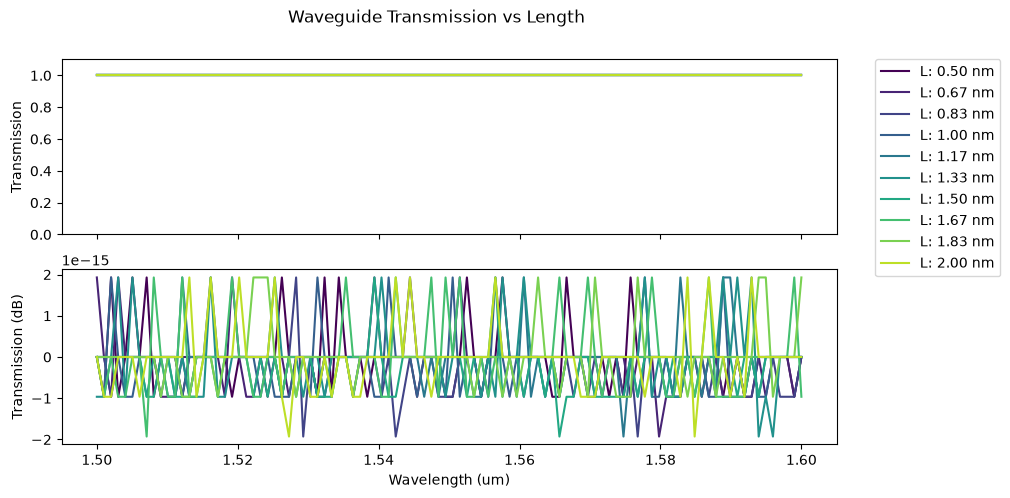

In [20]:
lengths = np.linspace(0.5, 2, 10) # from 0.5 to 2 microns, 10 points

results_per_length = {}
for i, length in enumerate(lengths):
    S = circuit(wl=wls, wg1={"length": length})

    # Normalized power
    power = jnp.abs(S["out","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    results_per_length[length] = {
        "wg_length": length,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_length, lengths, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))

for i, length in enumerate(lengths):
    axs[0].plot(wls, results_per_length[length]["power"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))
    axs[1].plot(wls, results_per_length[length]["loss"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Length")
fig.show()

### Supra-wavelength Lengths
Waveguides of 1.5 to 15um

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/1385241695.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


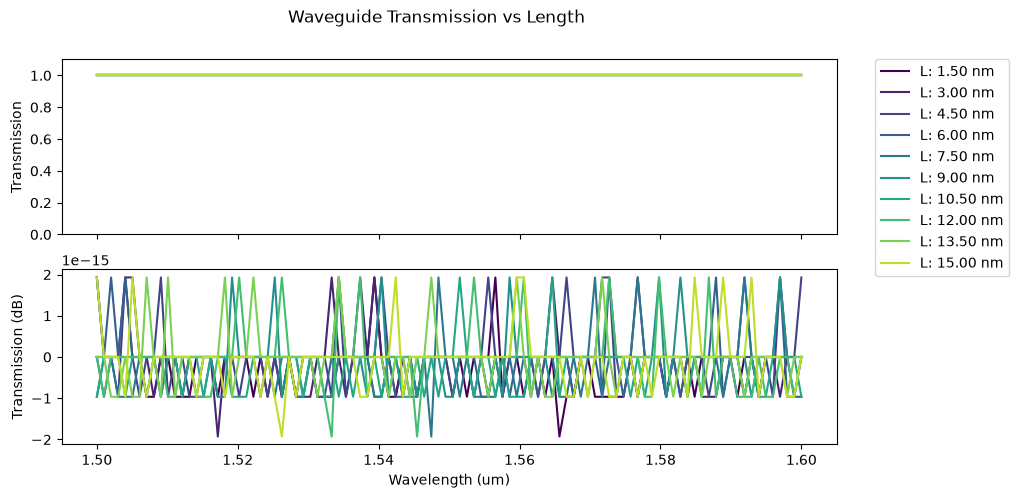

In [21]:
lengths = np.linspace(1.5, 15, 10) # from 0.5 to 2 microns, 10 points

results_per_length = {}
for i, length in enumerate(lengths):
    S = circuit(wl=wls, wg1={"length": length})

    # Normalized power
    power = jnp.abs(S["out","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    results_per_length[length] = {
        "wg_length": length,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_length, lengths, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))

for i, length in enumerate(lengths):
    axs[0].plot(wls, results_per_length[length]["power"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))
    axs[1].plot(wls, results_per_length[length]["loss"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Length")
fig.show()

## Conclusions - Gain Across Waveguide Length
* No significant effect on sub or supra scale.
* Transmission output across all wavelengths is close to 1.
* On a log dB scale, we can see microscopic variations +-2e-15
* No real difference between when lengths vary within or outside wavelengths (1.5um)

## Gain and Loss Across Lossy Waveguide Length
A waveguide with 0.1 dB/cm loss should present a drop on transmission power every cm (10,000 um)

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/2052375285.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


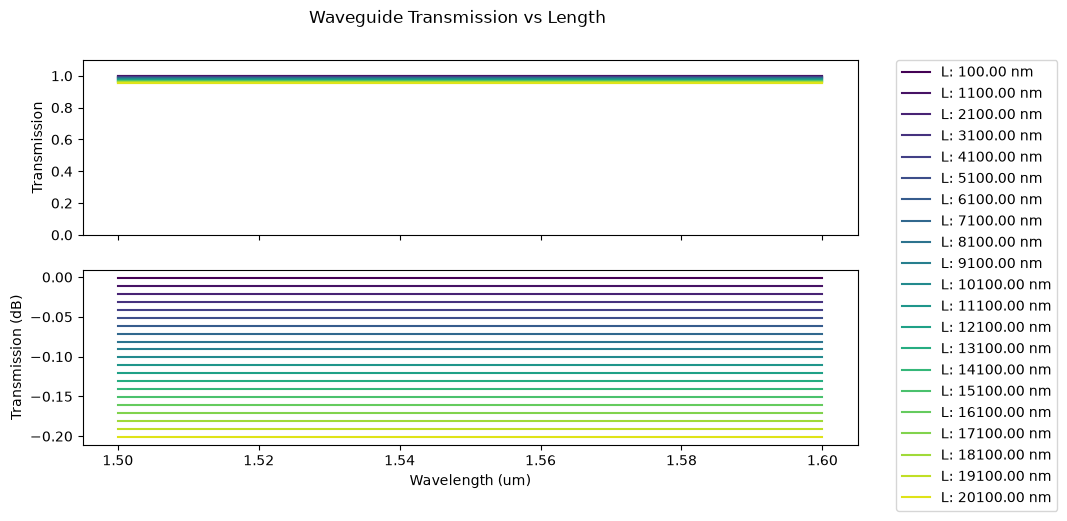

In [22]:
lengths = np.arange(100, 20100+1, 1000) # 10mm to 2cm. Units are in microns

results_per_length = {}
for i, length in enumerate(lengths):
    S = circuit(wl=wls, wg1={"length": length, "loss": 0.1})

    # Normalized power
    power = jnp.abs(S["out","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    results_per_length[length] = {
        "wg_length": length,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_length, lengths, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))

for i, length in enumerate(lengths):
    axs[0].plot(wls, results_per_length[length]["power"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))
    axs[1].plot(wls, results_per_length[length]["loss"], label=f"L: {length:0.2f} nm", color=cmap(i/len(lengths)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Length")
fig.show()

## Conclusions - Gain and Loss Across Lossy Waveguide Length
* Loss is Visible as Waveguide increases
* It corresponds closely with parametrized loss +- some small noise

## Phase Change Across Ideal Waveguide Length

### Sub-wavelength Lengths
1500-1600nm = 1.5 to 1.6um. So from 0.5 to 2 every 0.1um

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/2935372386.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


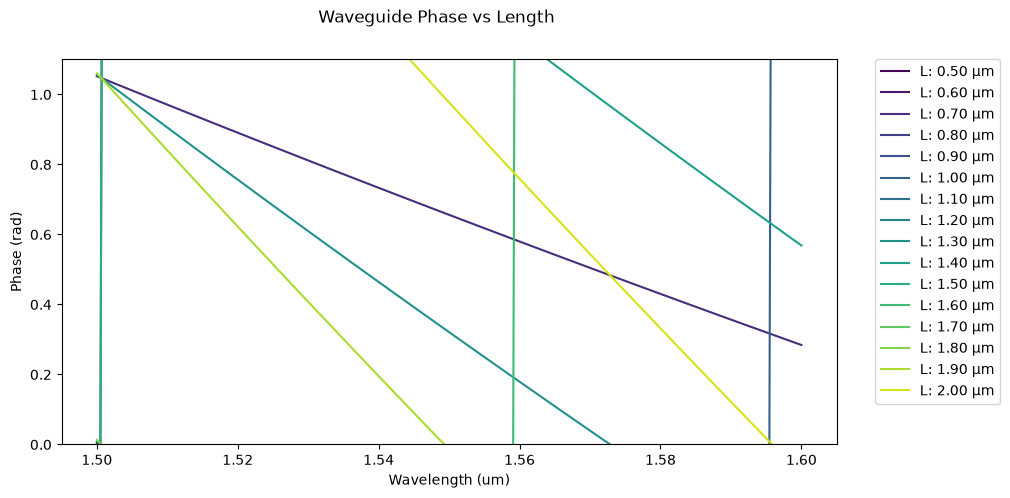

In [23]:
lengths = np.arange(0.5, 2+0.1, 0.1) # 0.5um to 2um. Units are in microns

results_per_length = {}
for i, length in enumerate(lengths):
    S = circuit(wl=wls, wg1={"length": length, "loss": 0.1})

    # Phase
    phase = jnp.angle(S["out","in"])
    results_per_length[length] = {
        "wg_length": length,
        "phase": phase,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_length, lengths, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs.set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))

for i, length in enumerate(lengths):
    axs.plot(wls, results_per_length[length]["phase"], label=f"L: {length:0.2f} μm", color=cmap(i/len(lengths)))

axs.set_ylim(0, 1.1)
axs.set_ylabel("Phase (rad)")
axs.set_xlabel("Wavelength (um)")
# axs.legend()
axs.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Phase vs Length")
fig.show()

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/876694612.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


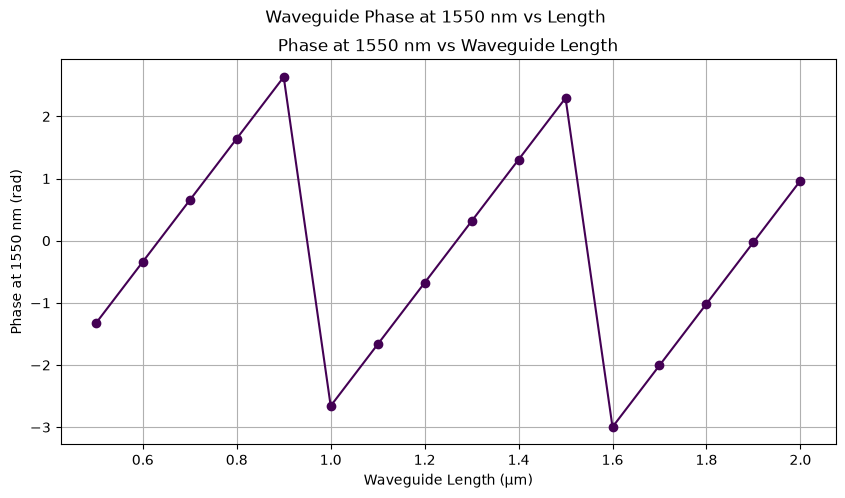

In [24]:
# Fix 1550nm wavelength and plot it's phase vs length. From 0.5 to 2 microns, 10 points
wl_1550_idx = wls.argsort()[np.abs(wls - 1.55).argmin()]+1
phases_at_1550 = []
for length in lengths:
    phases_at_1550.append(results_per_length[length]["phase"][wl_1550_idx])

phases_at_1550=np.array(phases_at_1550).flatten()

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs.set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))
axs.plot(lengths, phases_at_1550, marker="o")
axs.set_xlabel("Waveguide Length (μm)")
axs.set_ylabel("Phase at 1550 nm (rad)")
axs.set_title("Phase at 1550 nm vs Waveguide Length")
axs.grid()
plt.suptitle("Waveguide Phase at 1550 nm vs Length")
fig.show()

### Sub-wavelength Lengths
Large WG lengths should show a repetitive phase trend

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/770334166.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


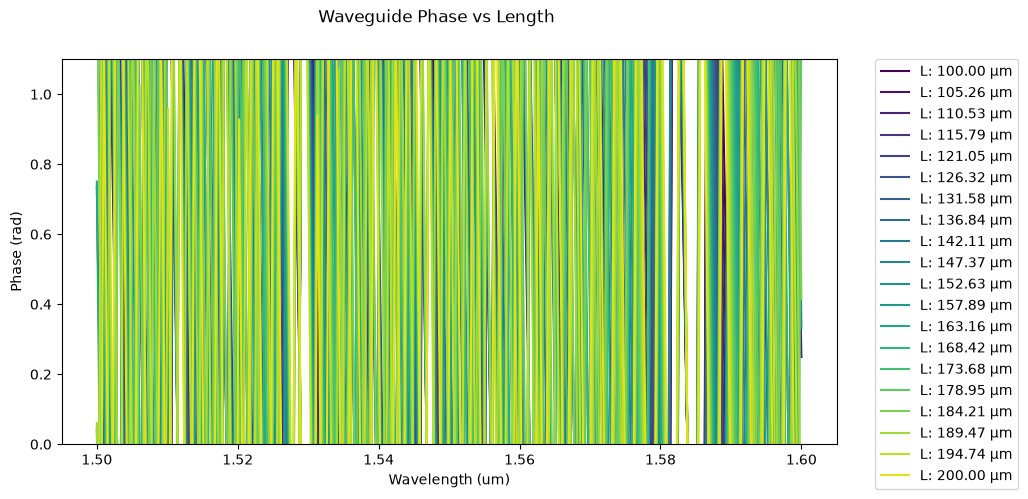

In [25]:
results_per_length = {}
lengths = np.linspace(100, 200, 20) # 10um to 200um, 100 points
for i, length in enumerate(lengths):
    S = circuit(wl=wls, wg1={"length": length})

    # Phase
    phase = jnp.angle(S["out","in"])    
    results_per_length[length] = {
        "wg_length": length,
        "phase": phase,
    }

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs.set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))

for i, length in enumerate(lengths):
    axs.plot(wls, results_per_length[length]["phase"], label=f"L: {length:0.2f} μm", color=cmap(i/len(lengths)))

axs.set_ylim(0, 1.1)
axs.set_ylabel("Phase (rad)")
axs.set_xlabel("Wavelength (um)")
# axs.legend()
axs.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Phase vs Length")
fig.show()

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11409/876694612.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


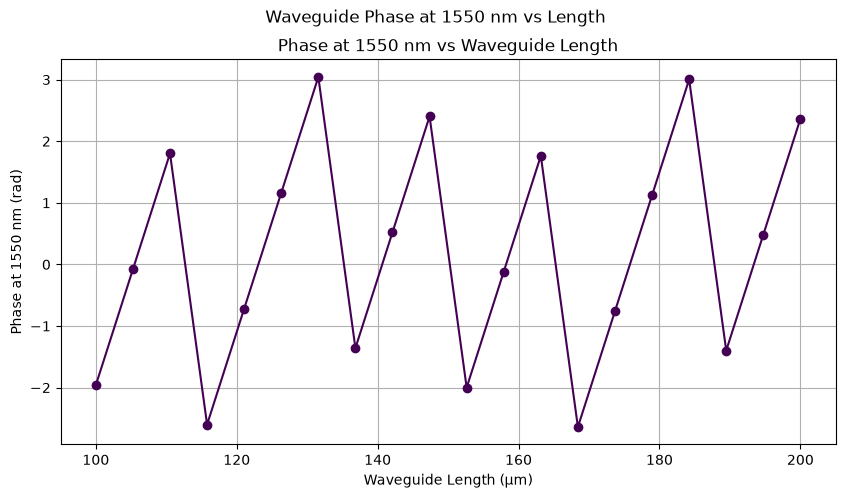

In [26]:
# Fix 1550nm wavelength and plot it's phase vs length. From 0.5 to 2 microns, 10 points
wl_1550_idx = wls.argsort()[np.abs(wls - 1.55).argmin()]+1
phases_at_1550 = []
for length in lengths:
    phases_at_1550.append(results_per_length[length]["phase"][wl_1550_idx])

phases_at_1550=np.array(phases_at_1550).flatten()

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs.set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(lengths)))))
axs.plot(lengths, phases_at_1550, marker="o")
axs.set_xlabel("Waveguide Length (μm)")
axs.set_ylabel("Phase at 1550 nm (rad)")
axs.set_title("Phase at 1550 nm vs Waveguide Length")
axs.grid()
plt.suptitle("Waveguide Phase at 1550 nm vs Length")
fig.show()

## Conclusions
* At sub-wavelength lengths it's easy to see and predict the phase value of waveguides.
* Phase varies both as length increases, but also as wavelength increases.
* At supra-lengths, it's only possible to see the periodic nature of a single wavelength. But it seems it has a higher sinoidal trend on its peaks